# Benchmark EDA

This notebook summarizes the current benchmark datasets stored in `data/benchmark` and saves publication-ready exploratory plots to `graphs/<benchmark_name>/`.

The notebook is executed and committed with outputs, so a reader can open it and see the figures without re-running the cells. Re-running the notebook will regenerate the PNG files from the CSV tables.

In [1]:

from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 220,
    "font.family": "Arial",
    "axes.titlesize": 14,
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
})

DATA_DIR = Path("..") / "data" / "benchmark"
GRAPH_ROOT = Path("..") / "graphs"
NUMERIC_COLS = ["QED", "SA", "MW", "LOGP", "RASCORE"]
BINARY_COLS = ["LIPINSKI", "LIPINSKI 0", "BRENK", "PAINS", "GLAXO"]

STATUS_ORDER = ["bad", "ambiguous", "good"]
STATUS_PALETTE = {
    "bad": "#d55e5e",
    "ambiguous": "#d99a2b",
    "good": "#3c8d62",
}
STRUCTURE_ORDER = [
    "good molecule",
    "bad molecule",
    "very bad molecule",
    "more active molecule",
    "less active molecule",
    "active metabolite",
    "pro-drug",
]
STRUCTURE_PALETTE = {
    "good molecule": "#3c8d62",
    "bad molecule": "#d55e5e",
    "very bad molecule": "#9e2f2f",
    "more active molecule": "#2f6fb0",
    "less active molecule": "#8fb6de",
    "active metabolite": "#5e9a8a",
    "pro-drug": "#a77cc2",
}
REASON_PALETTE = {
    "good": "#3c8d62",
    "bad extreme": "#9e2f2f",
    "bad medchem": "#b35a4a",
    "nature toxin": "#b85b90",
    "side effects": "#d99a2b",
    "addiction": "#c96f3f",
    "antitumor": "#7d6ab0",
}

DATASETS = {
    "absolute_scoring": {
        "label": "Absolute scoring benchmark",
        "file": "absolute_scoring.csv",
        "category_col": "STATUS",
        "category_order": STATUS_ORDER,
        "palette": STATUS_PALETTE,
        "secondary_col": "STATUS_REASON",
        "secondary_palette": REASON_PALETTE,
    },
    "pair_smiles": {
        "label": "Paired SMILES benchmark",
        "file": "pair_smiles.csv",
        "category_col": "CATEGORY",
        "category_order": STATUS_ORDER,
        "palette": STATUS_PALETTE,
    },
    "pair_structure": {
        "label": "Paired structure benchmark",
        "file": "pair_structure.csv",
        "category_col": "STATUS",
        "category_order": STRUCTURE_ORDER,
        "palette": STRUCTURE_PALETTE,
    },
}


In [2]:

def load_benchmark_csv(file_name: str) -> pd.DataFrame:
    df = pd.read_csv(DATA_DIR / file_name)
    for col in NUMERIC_COLS:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col].astype(str).str.replace(",", ".", regex=False), errors="coerce")
    for col in BINARY_COLS:
        if col in df.columns:
            df[col] = df[col].map(lambda x: str(x).strip().lower() == "true" if pd.notna(x) else pd.NA)
    return df


def save_current_figure(dataset_name: str, file_name: str):
    out_dir = GRAPH_ROOT / dataset_name
    out_dir.mkdir(parents=True, exist_ok=True)
    path = out_dir / file_name
    plt.savefig(path, bbox_inches="tight")
    return path


def ordered_values(df: pd.DataFrame, column: str, order=None):
    present = list(df[column].dropna().unique())
    if order is None:
        return present
    ordered = [value for value in order if value in present]
    ordered.extend([value for value in present if value not in ordered])
    return ordered


def palette_for(values, palette=None):
    if isinstance(palette, dict):
        return [palette.get(value, "#9aa0a6") for value in values]
    return sns.color_palette("Set2", n_colors=len(values))


loaded_data = {name: load_benchmark_csv(config["file"]) for name, config in DATASETS.items()}
summary = []
for name, config in DATASETS.items():
    df = loaded_data[name]
    category_col = config["category_col"]
    counts = df[category_col].value_counts().to_dict()
    summary.append({"dataset": name, "file": config["file"], "rows": len(df), "columns": len(df.columns), "groups": counts})

pd.DataFrame(summary)


,dataset,file,rows,columns,groups
0,absolute_scoring,absolute_scoring.csv,296,20,"{'good': 105, 'ambiguous': 97, 'bad': 94}"
1,pair_smiles,pair_smiles.csv,60,18,"{'bad': 20, 'good': 20, 'ambiguous': 20}"
2,pair_structure,pair_structure.csv,105,19,"{'bad molecule': 23, 'good molecule': 19, 'mor..."


## Helper Plotting Functions

The functions below are shared by all datasets. They keep the visual style consistent and save every generated plot into the matching subfolder under `graphs/`.

In [3]:

def plot_category_pie(df, dataset_name, category_col, title, file_name, order=None, palette=None):
    categories = ordered_values(df, category_col, order)
    counts = df[category_col].value_counts().reindex(categories).dropna()
    colors = palette_for(list(counts.index), palette)

    fig, ax = plt.subplots(figsize=(6.2, 4.8))
    wedges, _, autotexts = ax.pie(
        counts.values,
        labels=None,
        colors=colors,
        startangle=90,
        autopct=lambda pct: f"{pct:.1f}%\n({int(round(pct / 100 * counts.sum()))})",
        pctdistance=0.78,
        wedgeprops={"linewidth": 1.2, "edgecolor": "white"},
        textprops={"fontsize": 9},
    )
    ax.set_title(title, pad=14, weight="bold")
    ax.legend(wedges, counts.index, title=category_col, loc="center left", bbox_to_anchor=(1.0, 0.5), frameon=False)
    for item in autotexts:
        item.set_color("#202124")
    path = save_current_figure(dataset_name, file_name)
    plt.show()
    return path


def plot_numeric_boxplots(df, dataset_name, category_col, title, file_name, order=None, palette=None):
    categories = ordered_values(df, category_col, order)
    metrics = [col for col in NUMERIC_COLS if col in df.columns and df[col].notna().any()]
    long_df = df[[category_col] + metrics].melt(id_vars=category_col, var_name="metric", value_name="value").dropna()
    long_df = long_df[long_df[category_col].isin(categories)]

    fig, axes = plt.subplots(2, 3, figsize=(12, 7.2))
    axes = axes.ravel()
    colors = palette_for(categories, palette)
    for ax, metric in zip(axes, metrics):
        sub = long_df[long_df["metric"].eq(metric)]
        sns.boxplot(data=sub, x=category_col, y="value", order=categories, palette=colors, ax=ax, width=0.55, fliersize=2)
        medians = sub.groupby(category_col)["value"].median().reindex(categories)
        ymin, ymax = ax.get_ylim()
        y_offset = (ymax - ymin) * 0.025
        for idx, median in enumerate(medians):
            if pd.notna(median):
                ax.text(idx, median + y_offset, f"{median:.2f}", ha="center", va="bottom", fontsize=8, color="#202124")
        ax.set_title(metric, weight="bold")
        ax.set_xlabel("")
        ax.set_ylabel("")
        ax.tick_params(axis="x", rotation=18)
        if metric in {"QED", "RASCORE"}:
            ax.set_ylim(0, 1.05)
        if metric == "MW":
            ax.set_ylim(bottom=0)
    for ax in axes[len(metrics):]:
        ax.axis("off")
    fig.suptitle(title, y=1.02, weight="bold")
    fig.text(0.01, 0.5, "Descriptor value", rotation="vertical", va="center", fontsize=11)
    fig.tight_layout()
    path = save_current_figure(dataset_name, file_name)
    plt.show()
    return path


def plot_binary_rates(df, dataset_name, category_col, title, file_name, order=None, palette=None):
    categories = ordered_values(df, category_col, order)
    flags = [col for col in BINARY_COLS if col in df.columns]
    rate_rows = []
    for category in categories:
        sub = df[df[category_col].eq(category)]
        for flag in flags:
            values = sub[flag].dropna()
            rate_rows.append({"group": category, "flag": flag, "true_rate": values.mean() * 100 if len(values) else 0})
    rate_df = pd.DataFrame(rate_rows)

    fig, ax = plt.subplots(figsize=(10.5, 5.4))
    sns.heatmap(
        rate_df.pivot(index="flag", columns="group", values="true_rate").reindex(index=flags, columns=categories),
        annot=True,
        fmt=".0f",
        cmap="YlGnBu",
        vmin=0,
        vmax=100,
        linewidths=1,
        linecolor="white",
        cbar_kws={"label": "TRUE rate, %"},
        ax=ax,
    )
    ax.set_title(title, pad=14, weight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.tick_params(axis="x", rotation=25)
    ax.tick_params(axis="y", rotation=0)
    fig.tight_layout()
    path = save_current_figure(dataset_name, file_name)
    plt.show()
    return path


## Absolute Scoring Benchmark

This dataset is the primary benchmark for testing whether an LLM judge separates problematic, ambiguous, and good drug-like molecules. It includes expert categories, expert rationale fields, and calculated medicinal-chemistry descriptors.

In [4]:

absolute_scoring = loaded_data["absolute_scoring"]
display(absolute_scoring[["NAME", "STATUS", "STATUS_REASON", "CLASS", "QED", "SA", "MW", "LOGP", "RASCORE"]].head(8))


,NAME,STATUS,STATUS_REASON,CLASS,QED,SA,MW,LOGP,RASCORE
0,ACETONE,bad,bad extreme,solvent,0.40,1.65,58.08,0.60,0.991020
1,ACROLEIN,bad,bad extreme,reactive aldehyde,0.31,3.30,56.06,0.37,0.969429
2,ACRYLAMIDE,bad,bad extreme,industrial chemical,0.42,2.57,71.08,-0.34,0.983494
3,AFLATOXIN,bad,nature toxin,mycotoxin,0.75,4.01,312.28,2.28,0.076720
4,BENZENE,bad,bad extreme,aromatic solvent,0.44,1.00,78.11,1.69,0.978815
5,BROMO ACETONE,bad,bad extreme,lachrymator,0.49,2.53,136.98,0.97,0.993789
6,CARBON TETRACHLORIDE,bad,bad extreme,solvent,0.47,2.86,153.82,2.55,0.910971
7,CHLOROFORM,bad,bad extreme,solvent/anesthetic,0.43,3.18,119.38,1.99,0.964939


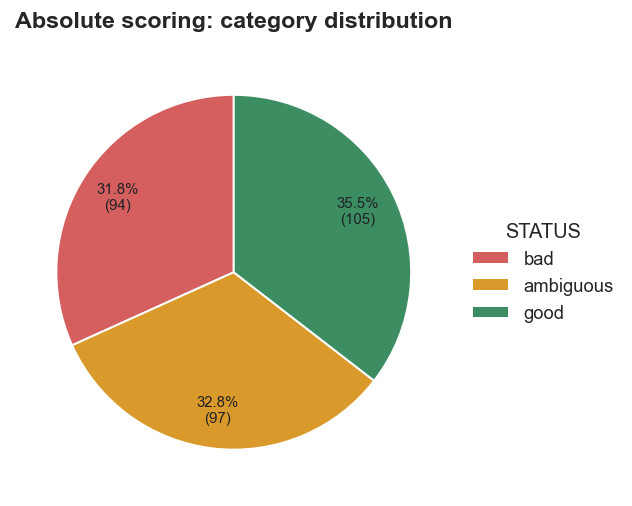

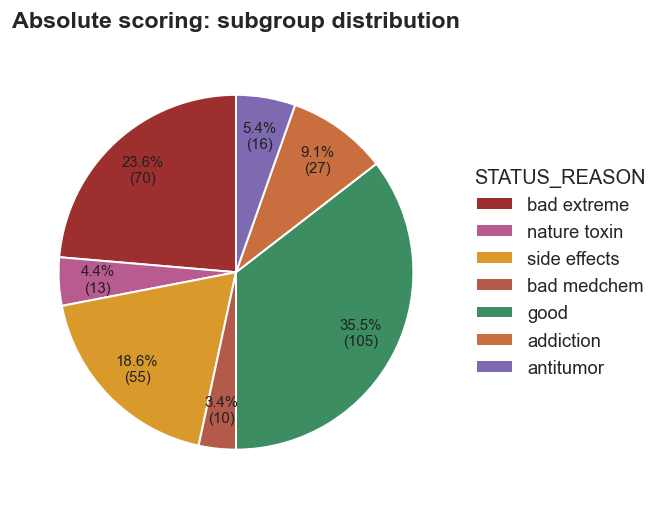

C:\Users\yarat\AppData\Local\Temp\ipykernel_25100\2425624666.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sub, x=category_col, y="value", order=categories, palette=colors, ax=ax, width=0.55, fliersize=2)
C:\Users\yarat\AppData\Local\Temp\ipykernel_25100\2425624666.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sub, x=category_col, y="value", order=categories, palette=colors, ax=ax, width=0.55, fliersize=2)
C:\Users\yarat\AppData\Local\Temp\ipykernel_25100\2425624666.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot

C:\Users\yarat\AppData\Local\Temp\ipykernel_25100\2425624666.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sub, x=category_col, y="value", order=categories, palette=colors, ax=ax, width=0.55, fliersize=2)
C:\Users\yarat\AppData\Local\Temp\ipykernel_25100\2425624666.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sub, x=category_col, y="value", order=categories, palette=colors, ax=ax, width=0.55, fliersize=2)


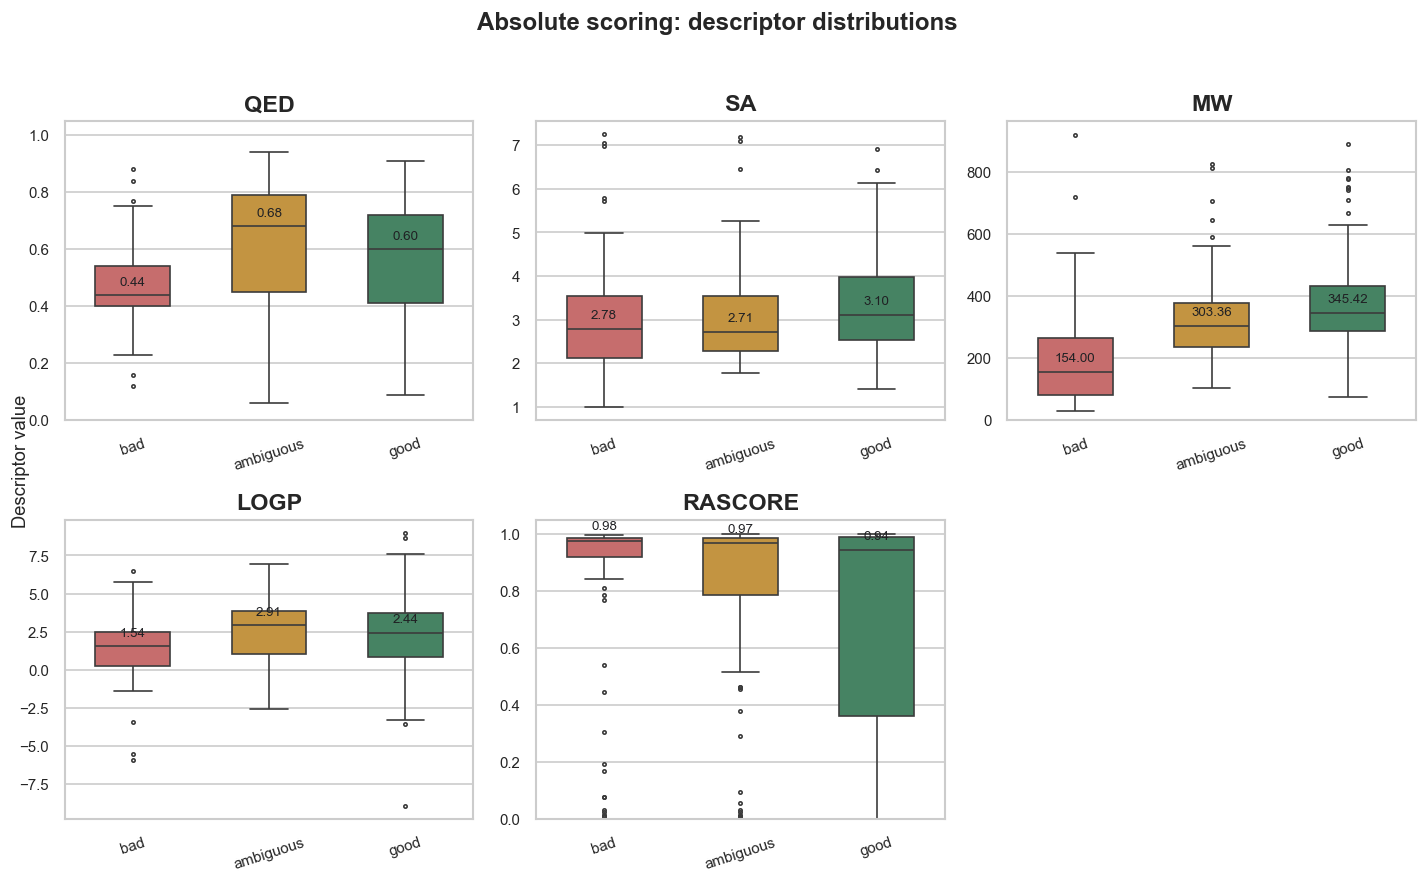

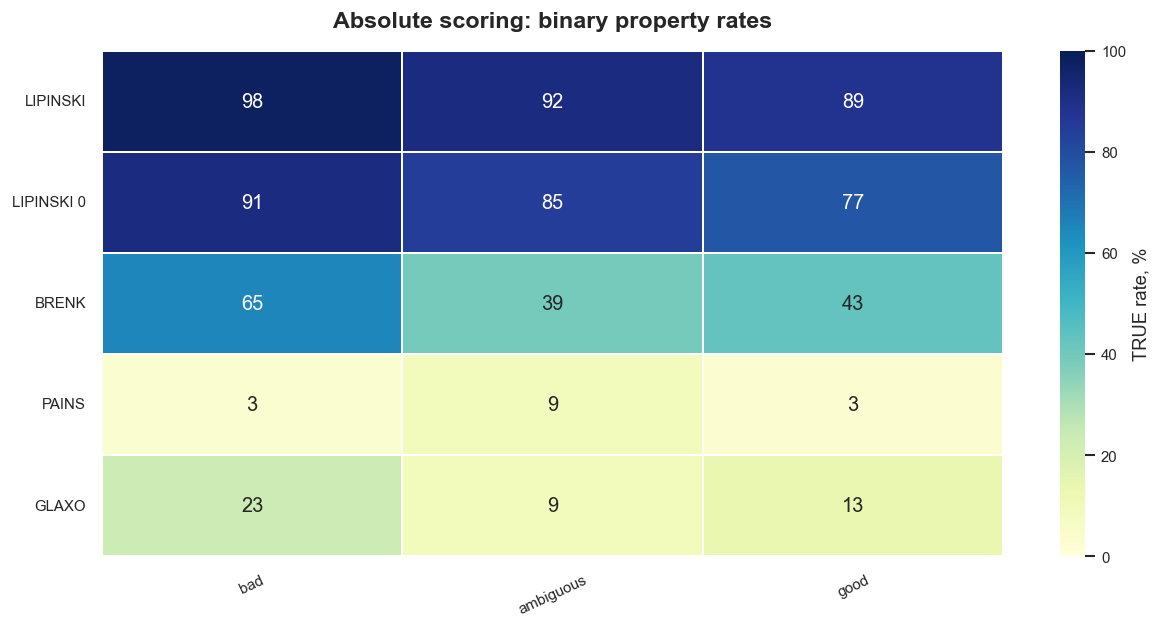

WindowsPath('../graphs/absolute_scoring/binary_property_rates.png')

In [5]:

cfg = DATASETS["absolute_scoring"]
plot_category_pie(absolute_scoring, "absolute_scoring", "STATUS", "Absolute scoring: category distribution", "category_distribution.png", cfg["category_order"], cfg["palette"])
plot_category_pie(absolute_scoring, "absolute_scoring", "STATUS_REASON", "Absolute scoring: subgroup distribution", "subgroup_distribution.png", palette=cfg["secondary_palette"])
plot_numeric_boxplots(absolute_scoring, "absolute_scoring", "STATUS", "Absolute scoring: descriptor distributions", "descriptor_boxplots.png", cfg["category_order"], cfg["palette"])
plot_binary_rates(absolute_scoring, "absolute_scoring", "STATUS", "Absolute scoring: binary property rates", "binary_property_rates.png", cfg["category_order"], cfg["palette"])


**Takeaway.** The absolute scoring set is close to balanced across the three top-level classes. Classical descriptors and structural alerts overlap between labels, especially around ambiguous molecules, which supports using this benchmark for testing whether an LLM judge integrates multiple medicinal-chemistry signals rather than relying on one filter.

## Paired SMILES Benchmark

This subset tests representation robustness by pairing canonical and non-canonical SMILES for the same molecules.

In [6]:

pair_smiles = loaded_data["pair_smiles"]
display(pair_smiles[["LATIN NAME", "CATEGORY", "CANONICAL SMILES", "NON-CANONICAL SMILES", "QED", "SA", "MW", "LOGP", "RASCORE"]].head(6))


,LATIN NAME,CATEGORY,CANONICAL SMILES,NON-CANONICAL SMILES,QED,SA,MW,LOGP,RASCORE
0,ALPHA-AMANITIN,bad,CC[C@H](C)[C@@H]1NC(=O)CNC(=O)[C@@H]2Cc3c([nH]...,O=C1[C@@H](NC(=O)[C@@H]2NC(CNC([C@H]([C@@H](C)...,0.12,7.25,918.98,-5.92,0.011854
1,MPTP,bad,CN1CCC(=CC1)C2=CC=CC=C2,c1cccc(C2CCN(C)CC=2)c1,0.63,1.95,173.26,2.41,0.985229
2,ROTENONE,bad,C=C(C)[C@H]1Cc2c(ccc3c2O[C@@H]2COc4cc(OC)c(OC)...,c1(c(OC)cc2OC[C@H]3Oc4c5c(ccc4C(=O)[C@H]3c2c1)...,0.74,3.87,394.42,3.70,0.032218
3,MONOMETHYL AURISTATIN E,bad,CO[C@H]([C@H](C(N[C@@H]([C@H](C1=CC=CC=C1)O)C)...,C(C)[C@H](C)[C@H](N(C)C([C@@H](NC(=O)[C@@H](NC...,0.16,4.98,717.99,3.53,0.009358
4,STRYCHNINE,bad,O=C1C[C@@H]2OCC=C3CN4CC[C@]56c7ccccc7N1[C@H]5[...,C1N2[C@H]3C[C@H]4C1=CCO[C@@H]1[C@H]4[C@H]4[C@@...,0.68,5.72,334.42,2.09,0.007539
5,CISAPRIDE,bad,COc1cc(N)c(Cl)cc1C(=O)NC1CCN(CCCOc2ccc(F)cc2)C...,c1c(c(cc(c1Cl)N)OC)C(=O)NC1CCN(CCCOc2ccc(cc2)F...,0.44,3.11,465.95,3.36,0.953597


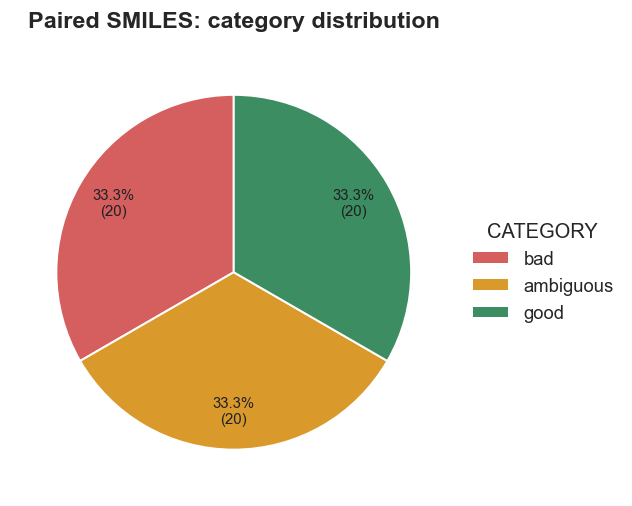

C:\Users\yarat\AppData\Local\Temp\ipykernel_25100\2425624666.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sub, x=category_col, y="value", order=categories, palette=colors, ax=ax, width=0.55, fliersize=2)
C:\Users\yarat\AppData\Local\Temp\ipykernel_25100\2425624666.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sub, x=category_col, y="value", order=categories, palette=colors, ax=ax, width=0.55, fliersize=2)
C:\Users\yarat\AppData\Local\Temp\ipykernel_25100\2425624666.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot

C:\Users\yarat\AppData\Local\Temp\ipykernel_25100\2425624666.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sub, x=category_col, y="value", order=categories, palette=colors, ax=ax, width=0.55, fliersize=2)
C:\Users\yarat\AppData\Local\Temp\ipykernel_25100\2425624666.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sub, x=category_col, y="value", order=categories, palette=colors, ax=ax, width=0.55, fliersize=2)


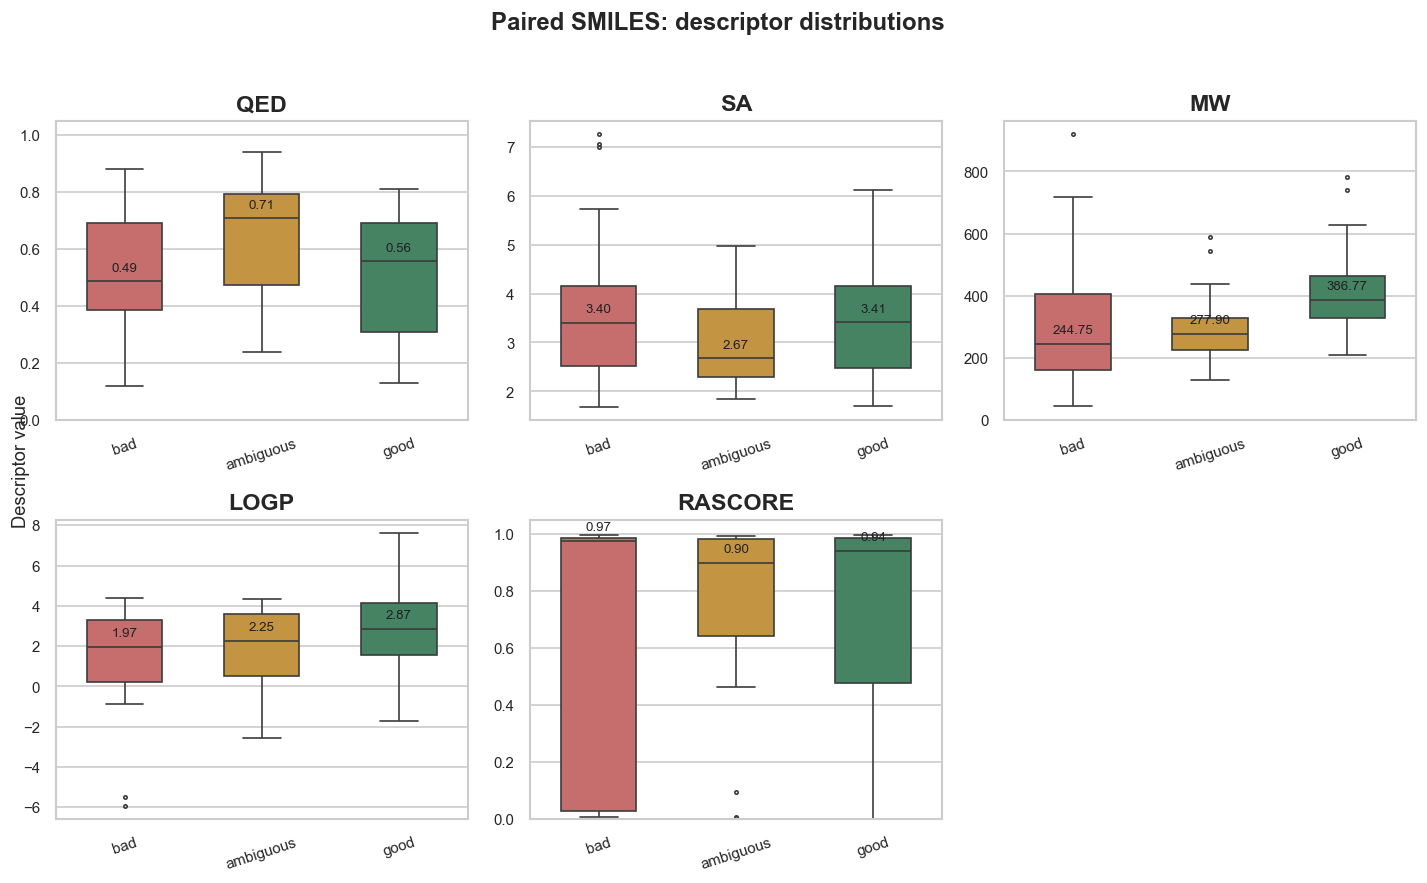

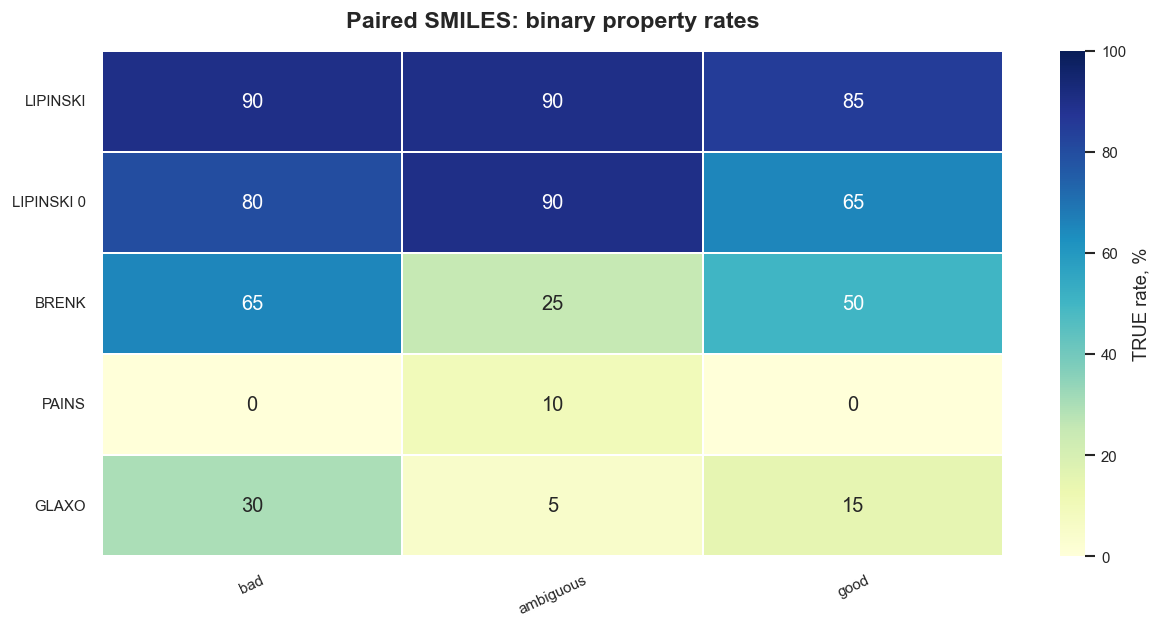

WindowsPath('../graphs/pair_smiles/binary_property_rates.png')

In [7]:

cfg = DATASETS["pair_smiles"]
plot_category_pie(pair_smiles, "pair_smiles", "CATEGORY", "Paired SMILES: category distribution", "category_distribution.png", cfg["category_order"], cfg["palette"])
plot_numeric_boxplots(pair_smiles, "pair_smiles", "CATEGORY", "Paired SMILES: descriptor distributions", "descriptor_boxplots.png", cfg["category_order"], cfg["palette"])
plot_binary_rates(pair_smiles, "pair_smiles", "CATEGORY", "Paired SMILES: binary property rates", "binary_property_rates.png", cfg["category_order"], cfg["palette"])


**Takeaway.** The paired SMILES subset is exactly balanced across bad, ambiguous, and good molecules. It spans broad descriptor ranges, so it is useful for testing whether the same molecule receives stable LLM scores under different valid SMILES strings.

## Paired Structure Benchmark

This subset compares structurally related molecules with different activity, safety, or developability status. It is designed to test whether the judge responds to small but chemically meaningful structural changes.

In [8]:

pair_structure = loaded_data["pair_structure"]
display(pair_structure[["NAME", "STATUS", "COMMENT", "EXPLANATION", "QED", "SA", "MW", "LOGP", "RASCORE"]].head(8))


,NAME,STATUS,COMMENT,EXPLANATION,QED,SA,MW,LOGP,RASCORE
0,ACETAMINOPHEN,good molecule,has an -OH group on the benzene ring,No notable adverse effects at normal dosage.,0.60,1.41,151.16,1.35,0.995031
1,PHENACETIN,bad molecule,has an ethoxy group on the benzene ring,Carcinogenic and nephrotoxic.,0.77,1.31,179.22,2.04,0.998590
2,S-IBUPROFEN,more active molecule,S-stereoisomer,Has the desired therapeutic properties.,0.82,2.19,206.28,3.07,0.989962
3,R-IBUPROFEN,less active molecule,R-stereoisomer,Inactive form that can be converted in vivo fr...,0.82,2.19,206.28,3.07,0.989962
4,R-THALIDOMIDE,good molecule,R-enantiomer,Has sedative and antiemetic activity.,0.72,2.60,258.23,0.09,0.981298
5,S-THALIDOMIDE,bad molecule,S-enantiomer,"Has teratogenic activity, although the practic...",0.72,2.60,258.23,0.09,0.981298
6,TERFENADINE,bad molecule,tert-butyl group on the benzene ring,Withdrawn from most markets because of cardiac...,0.40,2.86,471.69,6.45,0.970389
7,FEXOFENADINE,good molecule,one methyl group is replaced with -COOH,Terfenadine metabolite without the same toxic ...,0.34,3.02,501.67,5.51,0.534944


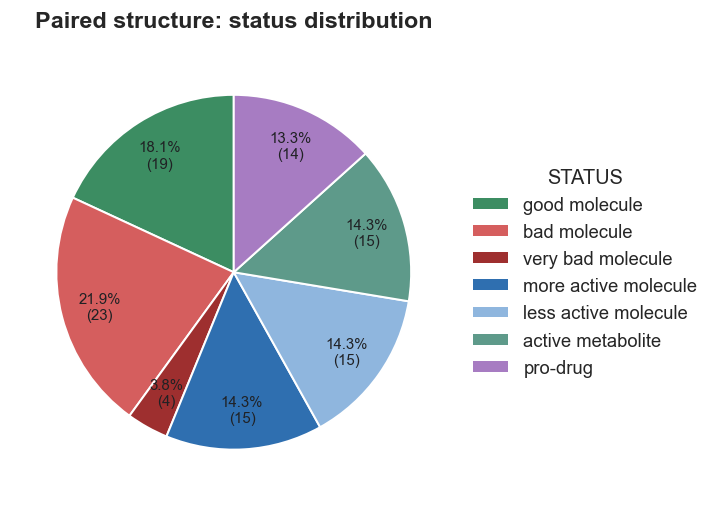

C:\Users\yarat\AppData\Local\Temp\ipykernel_25100\2425624666.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sub, x=category_col, y="value", order=categories, palette=colors, ax=ax, width=0.55, fliersize=2)
C:\Users\yarat\AppData\Local\Temp\ipykernel_25100\2425624666.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sub, x=category_col, y="value", order=categories, palette=colors, ax=ax, width=0.55, fliersize=2)


C:\Users\yarat\AppData\Local\Temp\ipykernel_25100\2425624666.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sub, x=category_col, y="value", order=categories, palette=colors, ax=ax, width=0.55, fliersize=2)
C:\Users\yarat\AppData\Local\Temp\ipykernel_25100\2425624666.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sub, x=category_col, y="value", order=categories, palette=colors, ax=ax, width=0.55, fliersize=2)


C:\Users\yarat\AppData\Local\Temp\ipykernel_25100\2425624666.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sub, x=category_col, y="value", order=categories, palette=colors, ax=ax, width=0.55, fliersize=2)


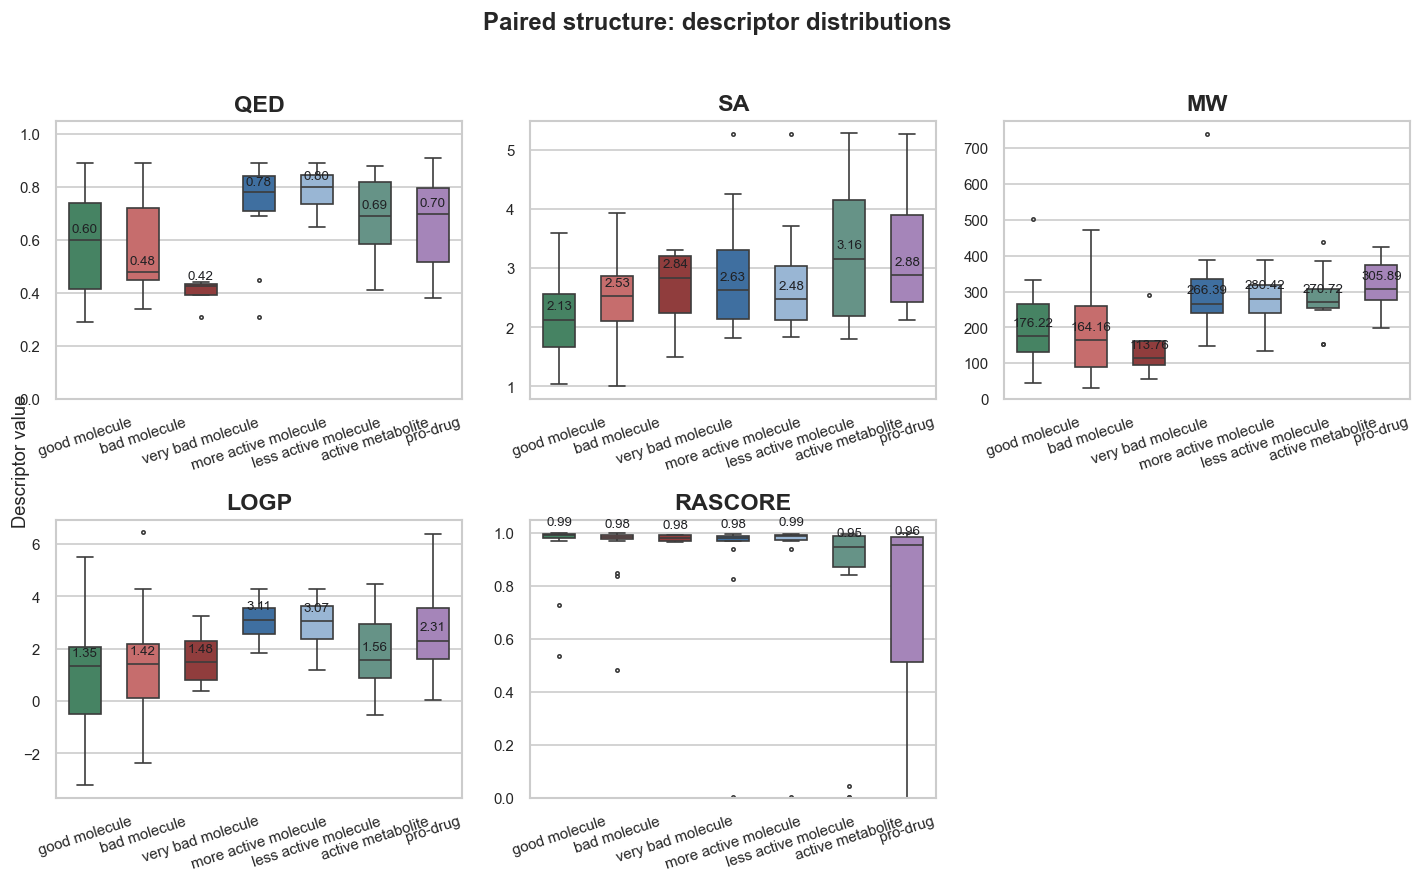

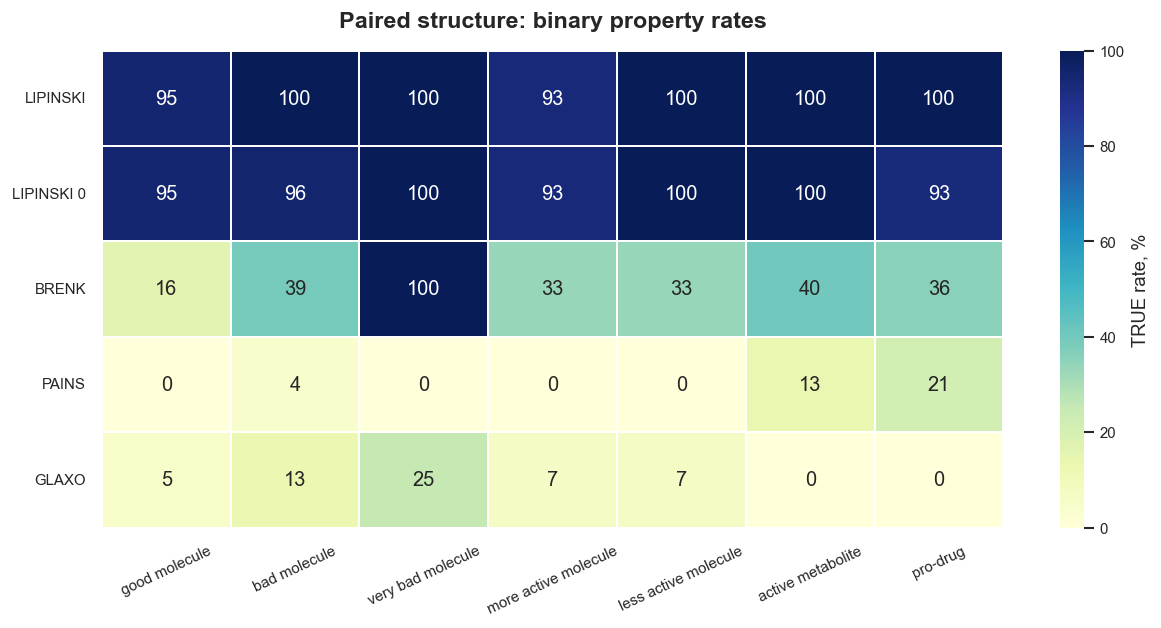

WindowsPath('../graphs/pair_structure/binary_property_rates.png')

In [9]:

cfg = DATASETS["pair_structure"]
plot_category_pie(pair_structure, "pair_structure", "STATUS", "Paired structure: status distribution", "status_distribution.png", cfg["category_order"], cfg["palette"])
plot_numeric_boxplots(pair_structure, "pair_structure", "STATUS", "Paired structure: descriptor distributions", "descriptor_boxplots.png", cfg["category_order"], cfg["palette"])
plot_binary_rates(pair_structure, "pair_structure", "STATUS", "Paired structure: binary property rates", "binary_property_rates.png", cfg["category_order"], cfg["palette"])


**Takeaway.** Many paired molecules have similar global descriptors, while their status depends on stereochemistry, metabolism, substituent changes, or safety liabilities. This makes the subset especially useful for evaluating fine-grained medicinal-chemistry reasoning.

## Saved Figures

The notebook saves figures into benchmark-specific folders:

- `graphs/absolute_scoring/`
- `graphs/pair_smiles/`
- `graphs/pair_structure/`

Each folder contains category/status distributions, descriptor boxplots, and binary property heatmaps.